In [1]:
import os, pickle
import pandas as pd
import ipywidgets as widgets
from IPython.display import display, clear_output
from plotters.gcd_plotter import plot_gcd_curves, load_gcd_data
from plotters.rate_plotter import plot_rate_performance

Dropdown(description='Plot Type:', options=('GCD', 'Rate', 'CV'), value='GCD')

Dropdown(description='Sample:', options=(), value=None)

SelectMultiple(description='File(s):', layout=Layout(height='100px'), options=(), value=())

Text(value='', description='Cycles:', placeholder='e.g. 1,2,3 or leave blank')

Text(value='', description='Label:')

Button(button_style='info', description='Add Sample', style=ButtonStyle())

Output()

Button(button_style='success', description='Plot', style=ButtonStyle())

Output()

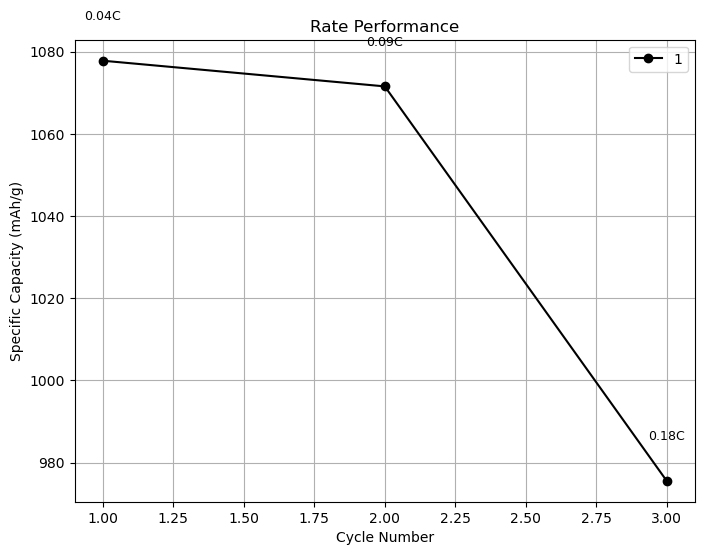

In [2]:
import os
import json
import pickle
import pandas as pd
import ipywidgets as widgets
from IPython.display import display, clear_output
from plotters import gcd_plotter, rate_plotter  # Assumes both plot functions exist

# --- Plot Type Selection ---
plot_type_dd = widgets.Dropdown(
    options=["GCD", "Rate", "CV"],
    value="GCD",
    description="Plot Type:"
)

# --- Project Folder Selection ---
project_folder = widgets.Text(
    value="",
    placeholder="Select your project folder",
    description="Project:",
    layout=widgets.Layout(width="70%")
)
browse_btn = widgets.Button(description="Browse…", layout=widgets.Layout(width="15%"))

def on_browse_clicked(_):
    from tkinter import Tk, filedialog
    tkroot = Tk(); tkroot.withdraw()
    folder = filedialog.askdirectory()
    tkroot.destroy()
    if folder:
        project_folder.value = folder
        update_sample_options()

browse_btn.on_click(on_browse_clicked)
folder_box = widgets.HBox([project_folder, browse_btn])

# --- Sample + File + Cycles + Label ---
sample_select = widgets.Dropdown(description="Sample:")
file_select = widgets.SelectMultiple(description="File(s):", layout=widgets.Layout(height='100px'))
cycle_input = widgets.Text(placeholder="e.g. 1,2,3 or leave blank", description="Cycles:")
label_input = widgets.Text(value="", description="Label:")

# --- Rate-only Inputs ---
theory_cap_input = widgets.FloatText(value=1675, description="Theoretical (mAh/g):")
rate_cycle_range = widgets.Text(value="1-3", description="Cycles to use:")
rate_box = widgets.VBox([theory_cap_input, rate_cycle_range])
rate_box.layout.display = 'none'

# Show/hide depending on plot type
def update_rate_widgets(*_):
    rate_box.layout.display = 'flex' if plot_type_dd.value == "Rate" else 'none'

plot_type_dd.observe(update_rate_widgets, names="value")

# --- Sample Addition ---
add_sample_btn = widgets.Button(description="Add Sample", button_style='info')
sample_preview = widgets.Output()
selected_samples = []  # Dicts: {sample, files, cycles, label}

def list_available_samples():
    base = project_folder.value
    selected_type = plot_type_dd.value
    result = []

    if os.path.isdir(base):
        for name in sorted(os.listdir(base)):
            sample_dir = os.path.join(base, name)
            if os.path.isdir(sample_dir):
                if selected_type == "GCD":
                    if any(os.path.isdir(os.path.join(sample_dir, f)) for f in ["GCD", "Rate"]):
                        result.append(name)
                else:
                    if os.path.isdir(os.path.join(sample_dir, selected_type)):
                        result.append(name)
    return result

def list_csv_files(sample, plot_type):
    base = os.path.join(project_folder.value, sample)
    files = []

    if plot_type == "GCD":
        for subfolder in ["GCD", "Rate"]:
            folder = os.path.join(base, subfolder)
            if os.path.isdir(folder):
                for f in os.listdir(folder):
                    if f.endswith(".csv"):
                        files.append(os.path.join(subfolder, f))
    else:
        folder = os.path.join(base, plot_type)
        if os.path.isdir(folder):
            for f in os.listdir(folder):
                if f.endswith(".csv"):
                    files.append(os.path.join(plot_type, f))

    return sorted(files)

def update_sample_options(*_):
    sample_select.options = list_available_samples()
    update_file_options()

def update_file_options(*_):
    sample = sample_select.value
    if sample:
        file_select.options = list_csv_files(sample, plot_type_dd.value)

project_folder.observe(update_sample_options, names="value")
sample_select.observe(update_file_options, names="value")
plot_type_dd.observe(update_sample_options, names="value")

def on_add_sample(_):
    sample = sample_select.value
    files = list(file_select.value)
    label = label_input.value.strip()
    if not sample or not files:
        print("⚠️ Please select sample and file(s).")
        return
    try:
        cycles = [int(c.strip()) for c in cycle_input.value.split(",") if c.strip()]
    except:
        cycles = None

    selected_samples.append({
        "sample": sample,
        "files": files,
        "cycles": cycles,
        "label": label
    })
    with sample_preview:
        print(f"✓ Added: {sample} | Files: {files} | Cycles: {cycles if cycles else 'All'} | Label: {label}")

add_sample_btn.on_click(on_add_sample)

# --- Plot Button ---
plot_btn = widgets.Button(description="Plot", button_style='success')
output = widgets.Output()

def on_plot_clicked(_):
    with output:
        output.clear_output()
        if not selected_samples:
            print("Please add at least one sample.")
            return

        plot_type = plot_type_dd.value
        all_groups = []  # list of {label, data_dict, mass_dict}

        for entry in selected_samples:
            sample = entry["sample"]
            files = entry["files"]
            cycles = entry["cycles"]
            label = entry["label"]
            base_path = os.path.join(project_folder.value, sample)

            data = {}
            masses = {}

            for rel_path in files:
                full_path = os.path.join(base_path, rel_path)
                folder = os.path.dirname(full_path)

                meta_path_pkl = os.path.join(folder, "metadata.pkl")
                meta_path_json = os.path.join(folder, "meta.json")
                mass_mg = 1.0

                if os.path.isfile(meta_path_pkl):
                    with open(meta_path_pkl, "rb") as f:
                        meta = pickle.load(f)
                    mass_mg = float(meta.get("mass_mg", 1.0))
                elif os.path.isfile(meta_path_json):
                    with open(meta_path_json) as f:
                        meta = json.load(f)
                    mass_mg = float(meta.get("mass_mg", 1.0))

                if not os.path.isfile(full_path):
                    print(f"⚠️ Missing file: {rel_path}")
                    continue

                try:
                    df = pd.read_csv(full_path)
                    if cycles:
                        df = df[df['cycle_number'].isin(cycles)]
                    key = f"{sample}_{os.path.splitext(os.path.basename(rel_path))[0]}"
                    data[key] = df
                    masses[key] = mass_mg
                except Exception as e:
                    print(f"❌ Failed to load {rel_path}: {e}")

            all_groups.append({
                "label": label if label else sample,
                "data": data,
                "masses": masses
            })

        if not all_groups:
            print("No valid data found.")
            return

        try:
            if plot_type == "GCD":
                fig, ax = gcd_plotter.plot_gcd_curves(all_groups)
            elif plot_type == "Rate":
                cap = theory_cap_input.value
                cycle_range = rate_cycle_range.value.strip().replace("to", "-")
                start, end = [int(c.strip()) for c in cycle_range.split("-")]
                fig, ax = rate_plotter.plot_rate_performance(all_groups, cap, start, end)
            else:
                print("⚠️ CV plotting not implemented yet.")
                return

            display(fig)

        except Exception as e:
            print(f"❌ Error while plotting: {e}")

plot_btn.on_click(on_plot_clicked)

# --- Display UI ---
display(folder_box)
display(plot_type_dd)
display(sample_select, file_select, cycle_input, label_input, add_sample_btn)
display(rate_box)
display(sample_preview)
display(plot_btn, output)
